## 1. Install and import libraries

#Null values, imbalence, out layers, duplicates

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [ ]:
DATA_PATH = "/content/drive/MyDrive/web-page-phishing.csv"
#https://www.kaggle.com/datasets/danielfernandon/web-page-phishing-dataset/data

TARGET_COLUMN = None
RANDOM_STATE = 42

## 3. Load the dataset

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.describe())
print("First five rows:")
display(df.head())

Dataset shape: (100077, 20)
          url_length         n_dots       n_hypens    n_underline  \
count  100077.000000  100077.000000  100077.000000  100077.000000   
mean       39.177683       2.224397       0.405188       0.137724   
std        47.971847       1.255046       1.285465       0.723995   
min         4.000000       1.000000       0.000000       0.000000   
25%        18.000000       2.000000       0.000000       0.000000   
50%        24.000000       2.000000       0.000000       0.000000   
75%        44.000000       2.000000       0.000000       0.000000   
max      4165.000000      24.000000      43.000000      21.000000   

             n_slash  n_questionmark        n_equal           n_at  \
count  100077.000000   100077.000000  100077.000000  100077.000000   
mean        1.135386        0.024391       0.215834       0.022143   
std         1.828526        0.167789       0.959802       0.268393   
min         0.000000        0.000000       0.000000       0.000000   


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 4. Dataset inspection

In [ ]:
print("Columns:")
print(df.columns.tolist())

print("Dataset info:")
df.info()

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Columns:
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection', 'phishing']
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100077 entries, 0 to 100076
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   url_length      100077 non-null  int64
 1   n_dots          100077 non-null  int64
 2   n_hypens        100077 non-null  int64
 3   n_underline     100077 non-null  int64
 4   n_slash         100077 non-null  int64
 5   n_questionmark  100077 non-null  int64
 6   n_equal         100077 non-null  int64
 7   n_at            100077 non-null  int64
 8   n_and           100077 non-null  int64
 9   n_exclamation   100077 non-null  int64
 10  n_space         100077 non-null  int64
 11  n_tilde         100077 non-null  int64
 

,0
url_length,0
n_dots,0
n_hypens,0
n_underline,0
n_slash,0
n_questionmark,0
n_equal,0
n_at,0
n_and,0
n_exclamation,0


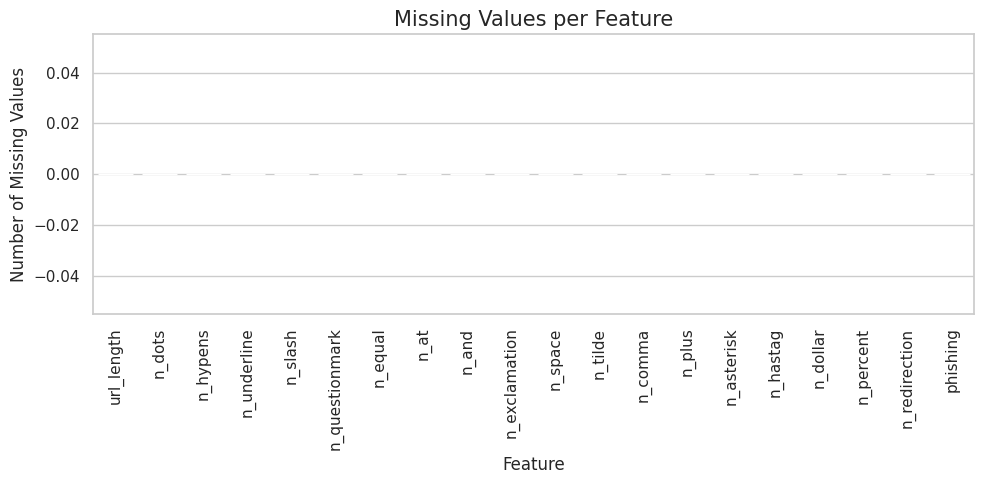

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.title("Missing Values per Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

## 5. Detect target column

In [ ]:
def detect_target_column(dataframe):
    common_targets = [
        "Result", "result",
        "class", "Class",
        "status", "Status",
        "label", "Label",
        "target", "Target",
        "phishing", "Phishing",
        "type", "Type"
    ]

    for col in common_targets:
        if col in dataframe.columns:
            return col

    return dataframe.columns[-1]

if TARGET_COLUMN is None:
    TARGET_COLUMN = detect_target_column(df)

print("Selected target column:", TARGET_COLUMN)
print("Target values before encoding:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

Selected target column: phishing
Target values before encoding:
phishing
0    63715
1    36362
Name: count, dtype: int64


In [ ]:
data_quality = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().sum().values / len(df)) * 100,
    "Unique Values": df.nunique().values
})

display(data_quality)

,Column,Data Type,Missing Values,Missing %,Unique Values
0,url_length,int64,0,0.0,490
1,n_dots,int64,0,0.0,23
2,n_hypens,int64,0,0.0,33
3,n_underline,int64,0,0.0,22
4,n_slash,int64,0,0.0,25
5,n_questionmark,int64,0,0.0,6
6,n_equal,int64,0,0.0,22
7,n_at,int64,0,0.0,15
8,n_and,int64,0,0.0,21
9,n_exclamation,int64,0,0.0,10


# **6.Duplicate analysis**

Rows before duplicate removal: 100077
Duplicate rows: 78186
Duplicate percentage: 78.13 %


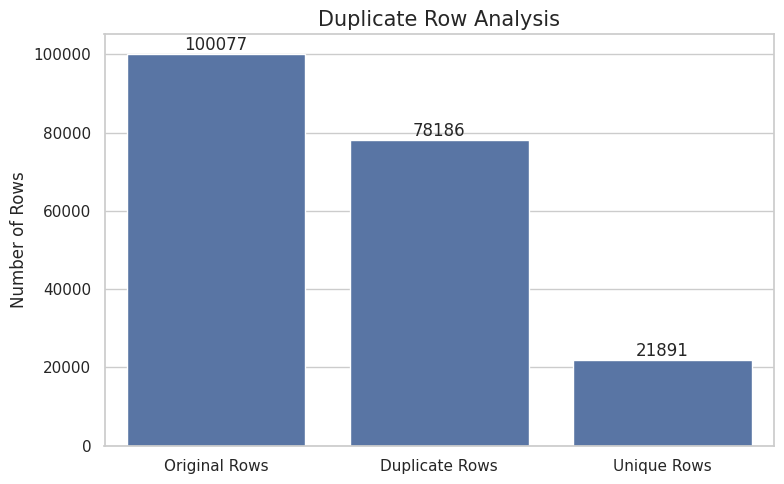

In [ ]:
total_rows_before = df.shape[0]
duplicate_rows = df.duplicated().sum()
df_clean=df
print("Rows before duplicate removal:", total_rows_before)
print("Duplicate rows:", duplicate_rows)
print("Duplicate percentage:", round((duplicate_rows / total_rows_before) * 100, 2), "%")

duplicate_summary = pd.DataFrame({
    "Category": ["Original Rows", "Duplicate Rows", "Unique Rows"],
    "Count": [
        total_rows_before,
        duplicate_rows,
        total_rows_before - duplicate_rows
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=duplicate_summary, x="Category", y="Count")
plt.title("Duplicate Row Analysis")
plt.xlabel("")
plt.ylabel("Number of Rows")

for index, value in enumerate(duplicate_summary["Count"]):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

# **8.Class balance plot**
Split into train and test first.
Balance only the training data.
Keep test data unchanged.

,Class,Count,Percentage
0,Legitimate,63715,63.665977
1,Phishing,36362,36.334023


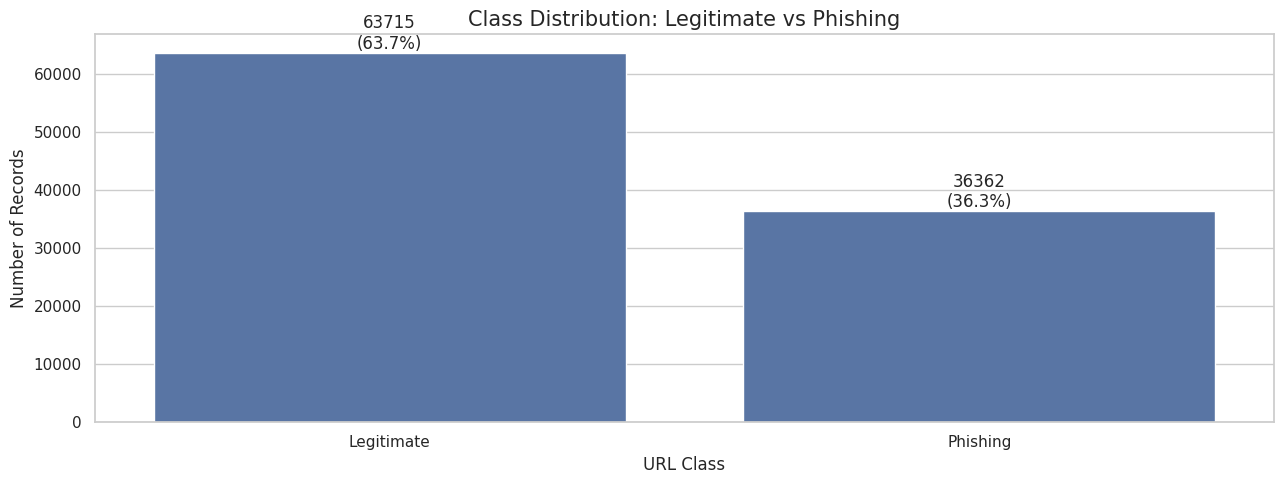

In [ ]:
class_counts = df_clean[TARGET_COLUMN].value_counts().sort_index()

class_labels = {
    0: "Legitimate",
    1: "Phishing"
}

class_balance = pd.DataFrame({
    "Class": [class_labels[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / class_counts.values.sum()) * 100
})

display(class_balance)

plt.figure(figsize=(13, 5))
sns.barplot(data=class_balance, x="Class", y="Count")
plt.title("Class Distribution: Legitimate vs Phishing")
plt.xlabel("URL Class")
plt.ylabel("Number of Records")

for index, row in class_balance.iterrows():
    plt.text(
        index,
        row["Count"],
        f'{row["Count"]}\n({row["Percentage"]:.1f}%)',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

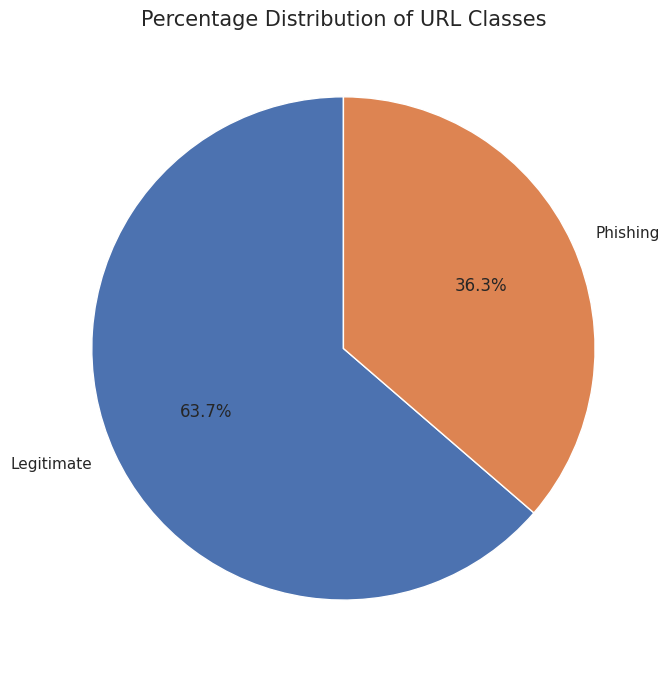

In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(
    class_balance["Count"],
    labels=class_balance["Class"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of URL Classes")
plt.tight_layout()
plt.show()

# **Feature distribution overview**

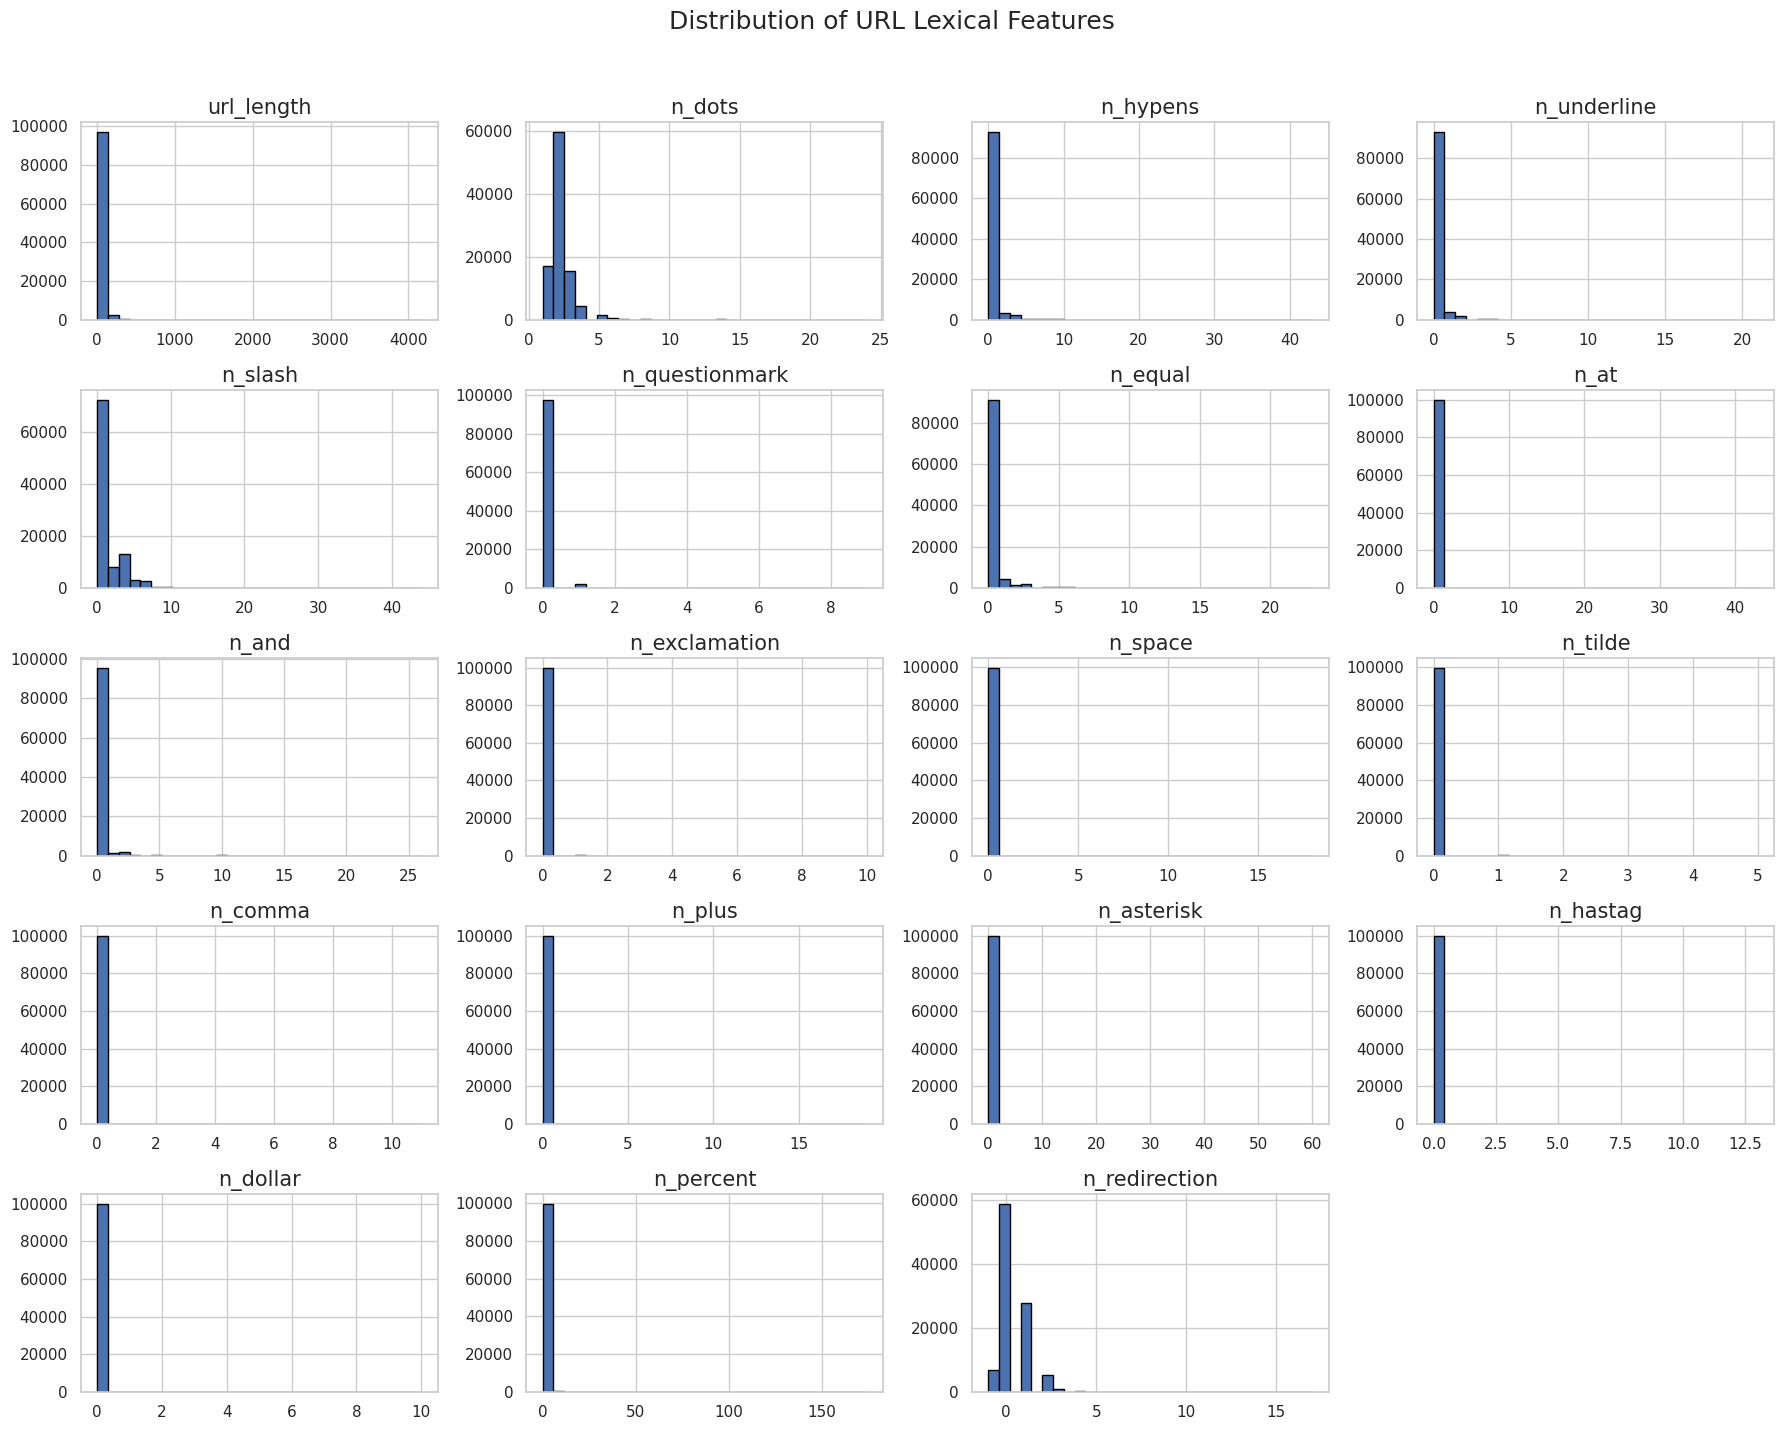

In [ ]:
feature_cols = [col for col in df_clean.columns if col != TARGET_COLUMN]

df_clean[feature_cols].hist(
    bins=30,
    figsize=(18, 14),
    edgecolor="black"
)

plt.suptitle("Distribution of URL Lexical Features", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# **URL length comparison**

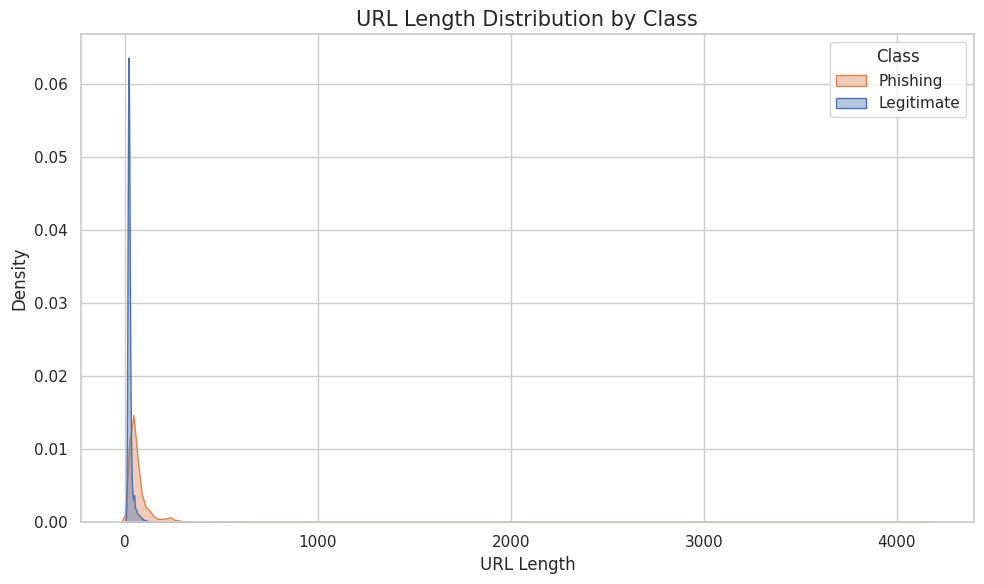

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_clean,
    x="url_length",
    hue=TARGET_COLUMN,
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("URL Length Distribution by Class")
plt.xlabel("URL Length")
plt.ylabel("Density")
plt.legend(title="Class", labels=["Phishing", "Legitimate"])
plt.tight_layout()
plt.show()

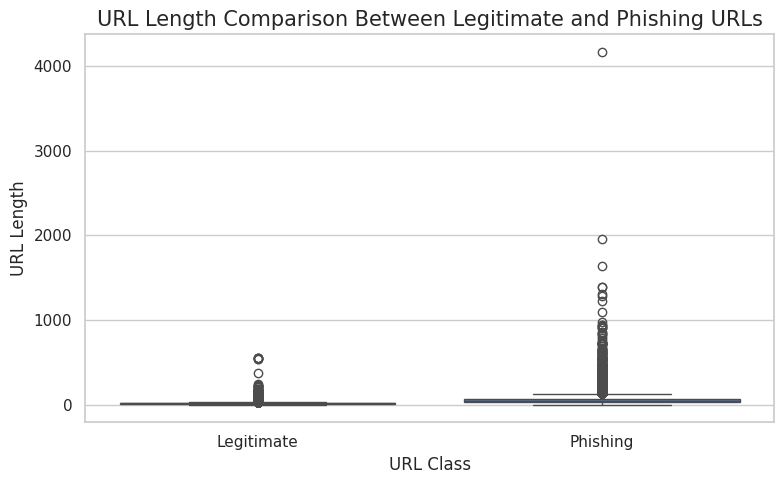

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x=TARGET_COLUMN,
    y="url_length"
)

plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.title("URL Length Comparison Between Legitimate and Phishing URLs")
plt.xlabel("URL Class")
plt.ylabel("URL Length")
plt.tight_layout()
plt.show()

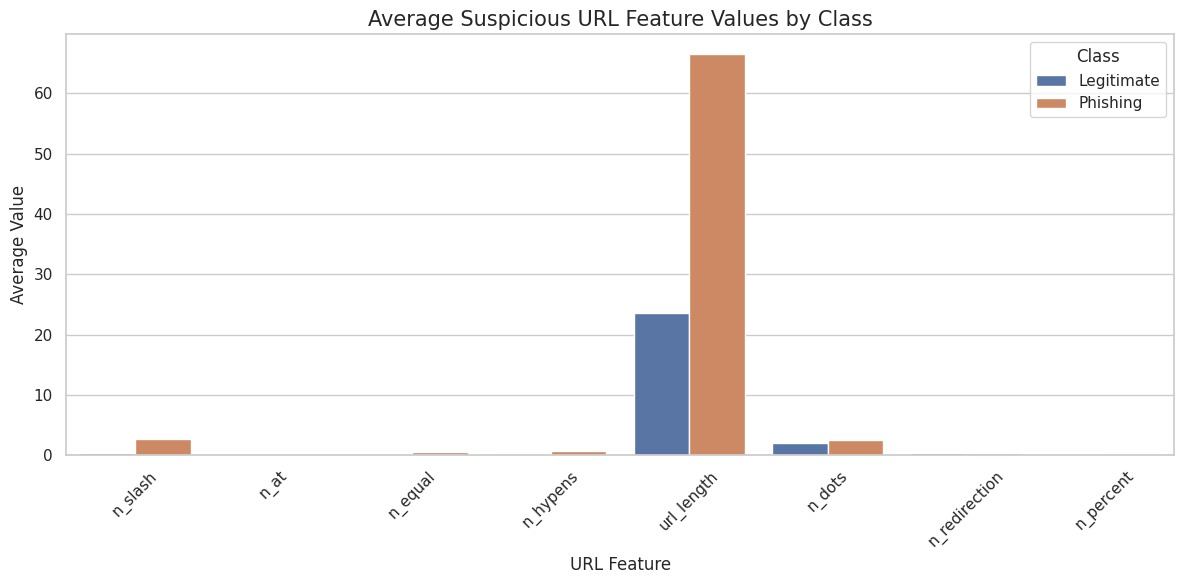

In [ ]:
important_features = [
    "n_slash",
    "n_at",
    "n_equal",
    "n_hypens",
    "url_length",
    "n_dots",
    "n_redirection",
    "n_percent"
]

important_features = [col for col in important_features if col in df_clean.columns]

important_means = df_clean.groupby(TARGET_COLUMN)[important_features].mean().T
important_means.columns = ["Legitimate", "Phishing"]

important_means_plot = important_means.reset_index().rename(columns={"index": "Feature"})
important_means_plot = important_means_plot.melt(
    id_vars="Feature",
    value_vars=["Legitimate", "Phishing"],
    var_name="Class",
    value_name="Average Value"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=important_means_plot,
    x="Feature",
    y="Average Value",
    hue="Class"
)

plt.title("Average Suspicious URL Feature Values by Class")
plt.xlabel("URL Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,url_length_group,Count,Phishing_Rate
0,0-25,54124,9.655606
1,26-50,25591,55.480442
2,51-75,10416,79.579493
3,76-100,4014,78.998505
4,101-150,3198,86.866792
5,151-200,870,97.816092
6,200+,1864,99.195279


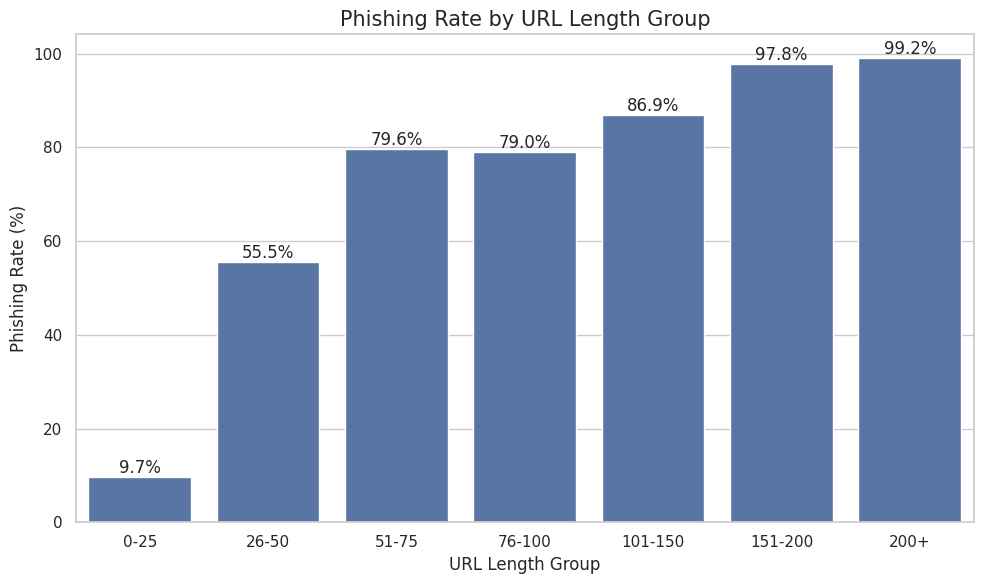

In [ ]:
df_clean["url_length_group"] = pd.cut(
    df_clean["url_length"],
    bins=[0, 25, 50, 75, 100, 150, 200, np.inf],
    labels=["0-25", "26-50", "51-75", "76-100", "101-150", "151-200", "200+"]
)

url_length_group_analysis = df_clean.groupby("url_length_group")[TARGET_COLUMN].agg(
    Count="count",
    Phishing_Rate="mean"
).reset_index()

url_length_group_analysis["Phishing_Rate"] = url_length_group_analysis["Phishing_Rate"] * 100

display(url_length_group_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=url_length_group_analysis,
    x="url_length_group",
    y="Phishing_Rate"
)

plt.title("Phishing Rate by URL Length Group")
plt.xlabel("URL Length Group")
plt.ylabel("Phishing Rate (%)")

for index, row in url_length_group_analysis.iterrows():
    plt.text(
        index,
        row["Phishing_Rate"],
        f'{row["Phishing_Rate"]:.1f}%',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

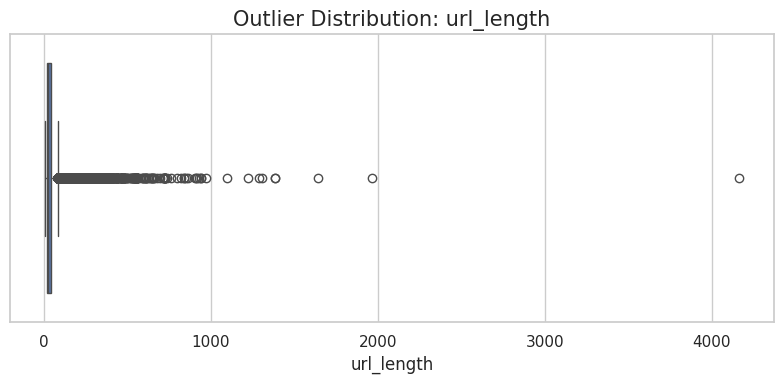

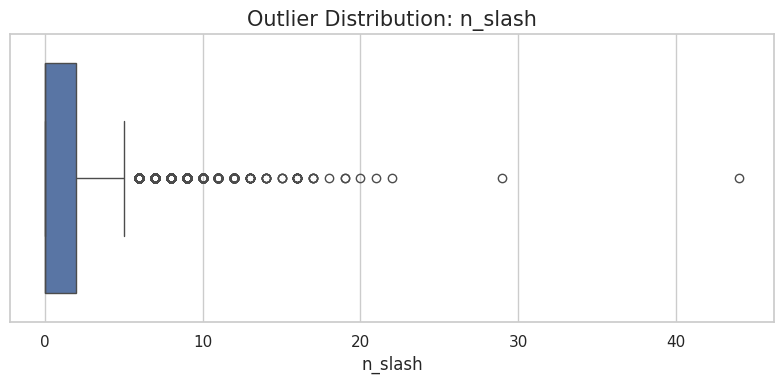

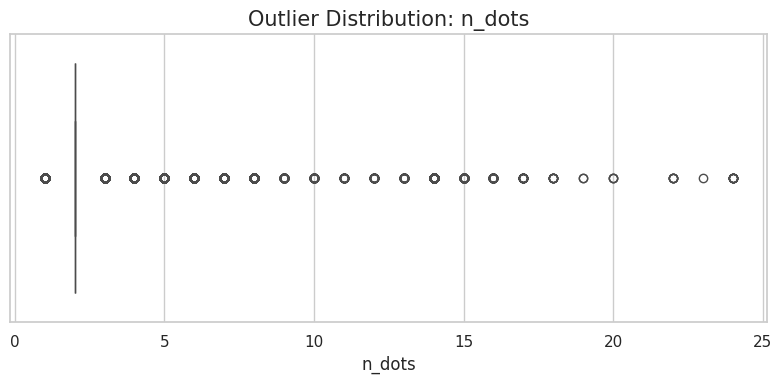

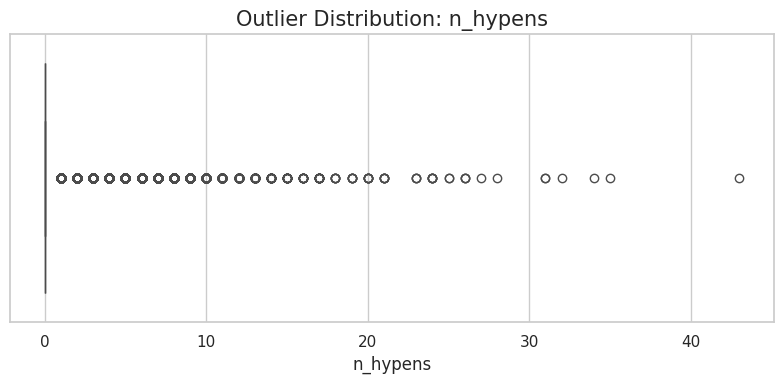

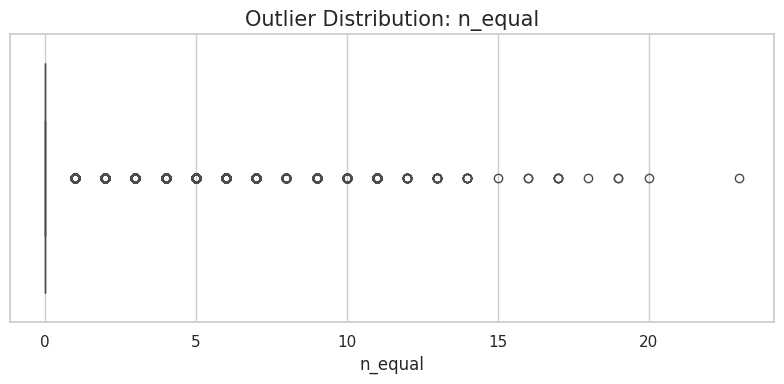

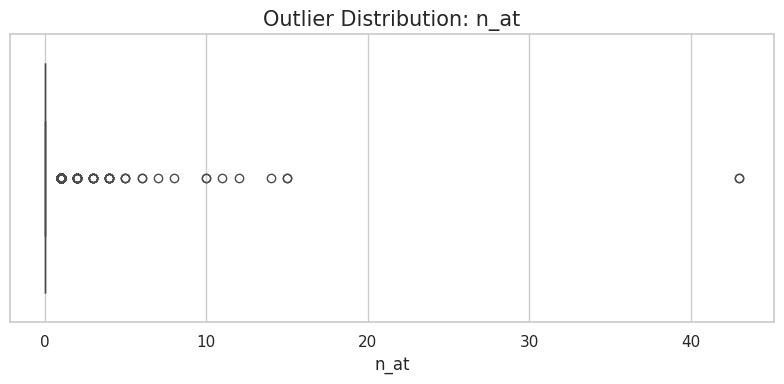

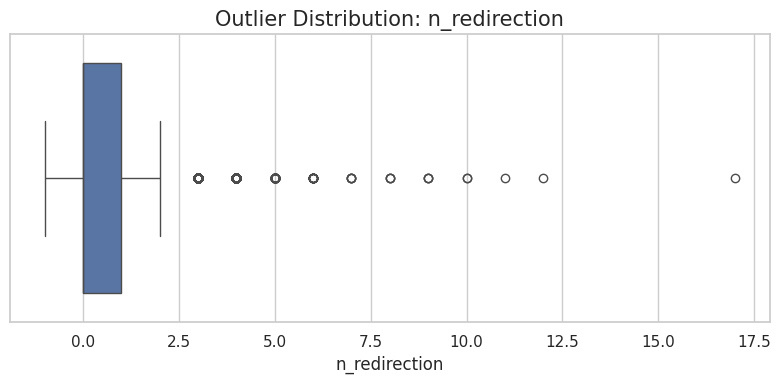

In [ ]:
selected_features = [
    "url_length",
    "n_slash",
    "n_dots",
    "n_hypens",
    "n_equal",
    "n_at",
    "n_redirection"
]

selected_features = [col for col in selected_features if col in df_clean.columns]

for feature in selected_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_clean, x=feature)
    plt.title(f"Outlier Distribution: {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

In [ ]:
Q1 = df_clean["url_length"].quantile(0.25)
Q3 = df_clean["url_length"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df_clean[df_clean["url_length"] > upper_bound]

print("Number of url_length outliers:", outliers.shape[0])
print("Outlier percentage:", round((outliers.shape[0] / df_clean.shape[0]) * 100, 2), "%")

print("\nClass distribution among URL length outliers:")
print(outliers["phishing"].value_counts())
print(outliers["phishing"].value_counts(normalize=True) * 100)

Q1: 18.0
Q3: 44.0
IQR: 26.0
Lower bound: -21.0
Upper bound: 83.0
Number of url_length outliers: 8125
Outlier percentage: 8.12 %

Class distribution among URL length outliers:
phishing
1    7213
0     912
Name: count, dtype: int64
phishing
1    88.775385
0    11.224615
Name: proportion, dtype: float64


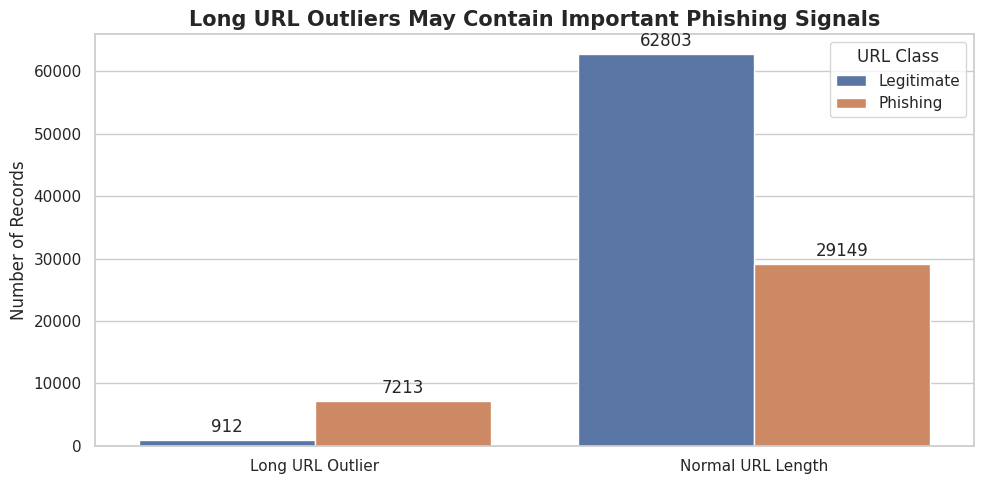

In [ ]:
df_outlier_check = df_clean.copy()

df_outlier_check["URL Length Group"] = np.where(
    df_outlier_check["url_length"] > upper_bound,
    "Long URL Outlier",
    "Normal URL Length"
)

outlier_class = df_outlier_check.groupby(
    ["URL Length Group", "phishing"]
).size().reset_index(name="Count")

outlier_class["URL Class"] = outlier_class["phishing"].map({
    0: "Legitimate",
    1: "Phishing"
})

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=outlier_class,
    x="URL Length Group",
    y="Count",
    hue="URL Class"
)

plt.title("Long URL Outliers May Contain Important Phishing Signals", fontweight="bold")
plt.xlabel("")
plt.ylabel("Number of Records")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

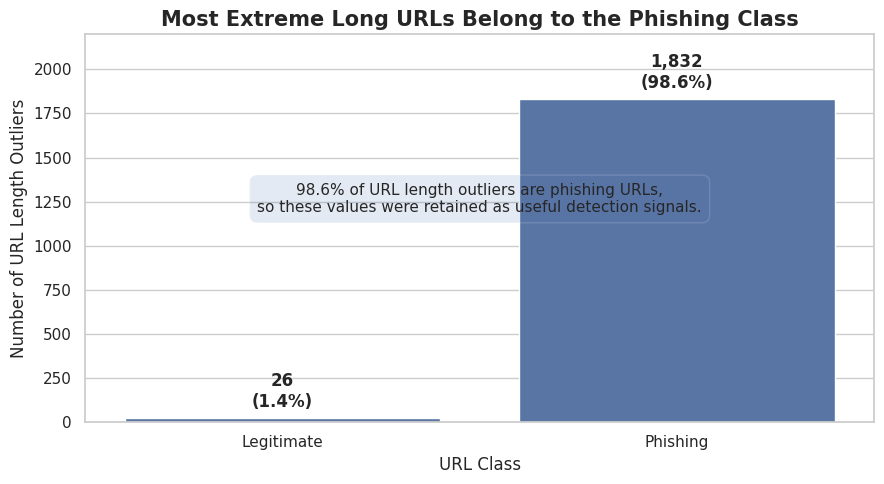

In [ ]:
# Storytelling plot: URL length outliers are mostly phishing

outlier_summary = pd.DataFrame({
    "URL Class": ["Legitimate", "Phishing"],
    "Count": [26, 1832]
})

outlier_summary["Percentage"] = (
    outlier_summary["Count"] / outlier_summary["Count"].sum()
) * 100

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=outlier_summary,
    x="URL Class",
    y="Count"
)

plt.title(
    "Most Extreme Long URLs Belong to the Phishing Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("URL Class")
plt.ylabel("Number of URL Length Outliers")

for index, row in outlier_summary.iterrows():
    ax.text(
        index,
        row["Count"] + 40,
        f"{int(row['Count']):,}\n({row['Percentage']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.text(0.5,max(outlier_summary["Count"]) * 0.65,"98.6% of URL length outliers are phishing URLs,\nso these values were retained as useful detection signals.",ha="center",fontsize=11,bbox=dict(boxstyle="round,pad=0.5", alpha=0.15))

plt.ylim(0, max(outlier_summary["Count"]) * 1.2)
plt.tight_layout()
plt.show()


Logistic Regression Results
---------------------------------------------
Training Accuracy : 0.8620
Testing Accuracy  : 0.8610
Precision         : 0.8272
Recall            : 0.7806
F1 Score          : 0.8032
ROC AUC           : 0.9329


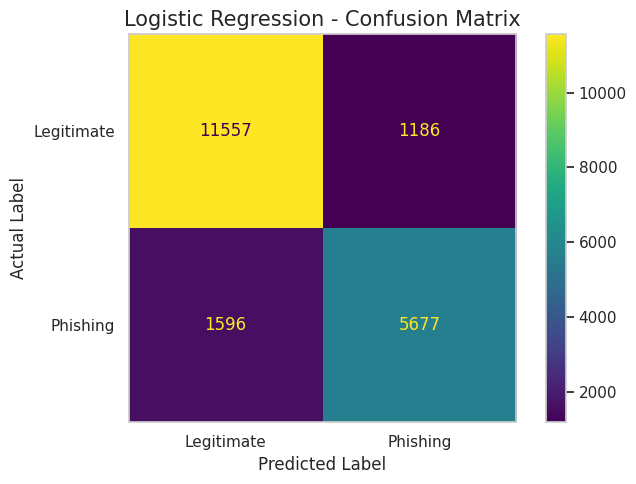

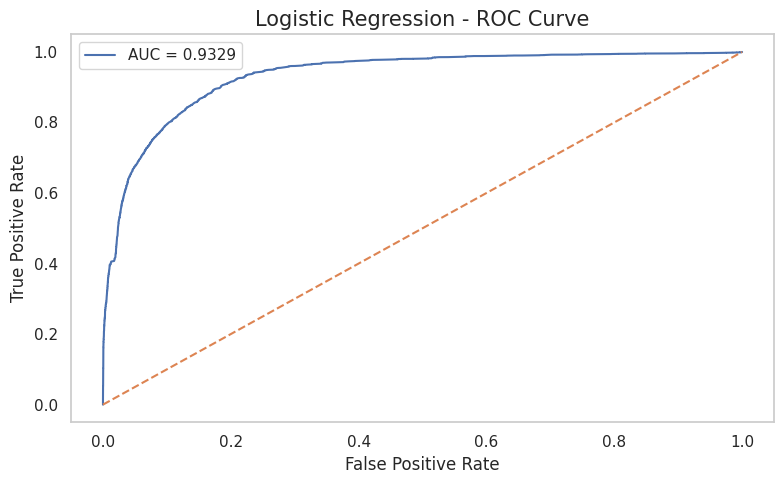

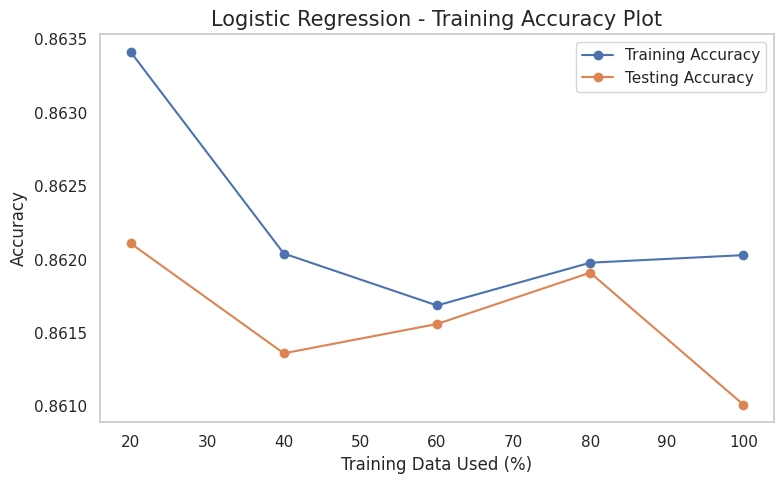

In [ ]:
# =========================
# 1: Logistic Regression
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -------------------------
# Data setup
# -------------------------

RANDOM_STATE = 42
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

results = []

# -------------------------
# Helper functions
# -------------------------

def plot_training_accuracy(model, model_name, use_sample_weight=False):
    train_sizes = np.linspace(0.2, 1.0, 5)
    train_acc = []
    test_acc = []

    for frac in train_sizes:
        if frac < 1.0:
            X_sub, _, y_sub, _ = train_test_split(
                X_train,
                y_train,
                train_size=frac,
                random_state=RANDOM_STATE,
                stratify=y_train
            )
        else:
            X_sub, y_sub = X_train, y_train

        temp_model = clone(model)

        if use_sample_weight:
            weights = compute_sample_weight(class_weight="balanced", y=y_sub)
            temp_model.fit(X_sub, y_sub, sample_weight=weights)
        else:
            temp_model.fit(X_sub, y_sub)

        train_acc.append(accuracy_score(y_sub, temp_model.predict(X_sub)))
        test_acc.append(accuracy_score(y_test, temp_model.predict(X_test)))

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes * 100, train_acc, marker="o", label="Training Accuracy")
    plt.plot(train_sizes * 100, test_acc, marker="o", label="Testing Accuracy")
    plt.title(f"{model_name} - Training Accuracy Plot")
    plt.xlabel("Training Data Used (%)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, model_name, use_sample_weight=False):
    if use_sample_weight:
        weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model.fit(X_train, y_train, sample_weight=weights)
    else:
        model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_prob)

    print(f"\n{model_name} Results")
    print("-" * 45)
    print(f"Training Accuracy : {train_accuracy:.4f}")
    print(f"Testing Accuracy  : {test_accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC AUC           : {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)

    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    )
    disp.plot(ax=ax, cmap="viridis", values_format="d", colorbar=True)
    ax.grid(False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # Training accuracy plot
    plot_training_accuracy(model, model_name, use_sample_weight)

    return {
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }


# -------------------------
# Model 1
# -------------------------

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

lr_result = evaluate_model(logistic_model, "Logistic Regression")
results.append(lr_result)


Random Forest Results
---------------------------------------------
Training Accuracy : 0.9210
Testing Accuracy  : 0.8867
Precision         : 0.8261
Recall            : 0.8716
F1 Score          : 0.8483
ROC AUC           : 0.9537


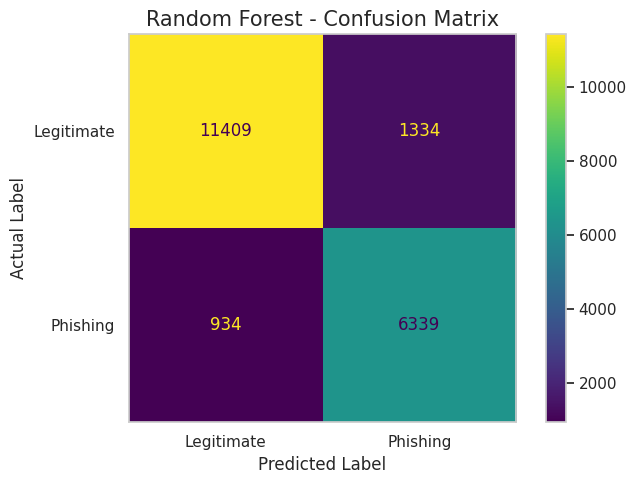

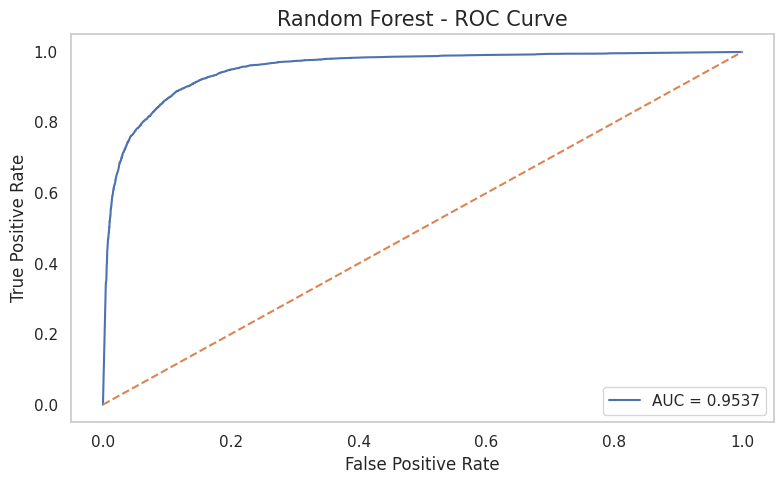

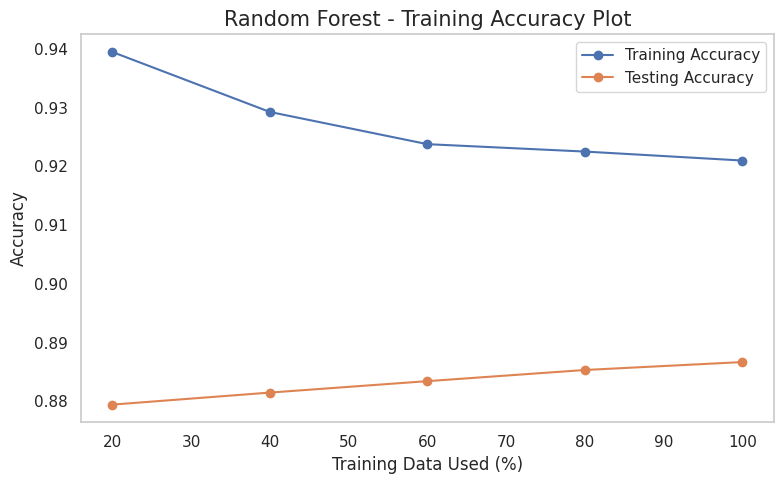

In [ ]:
# =========================
# 2: Random Forest
# =========================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_result = evaluate_model(random_forest_model, "Random Forest")
results.append(rf_result)


Gradient Boosting Results
---------------------------------------------
Training Accuracy : 0.8790
Testing Accuracy  : 0.8775
Precision         : 0.7861
Recall            : 0.9108
F1 Score          : 0.8439
ROC AUC           : 0.9531


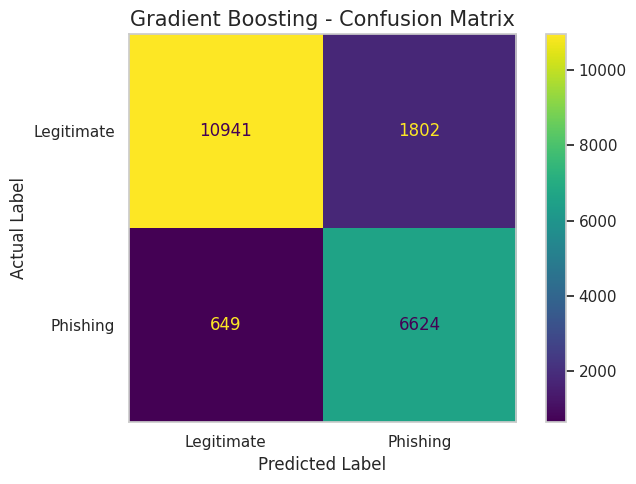

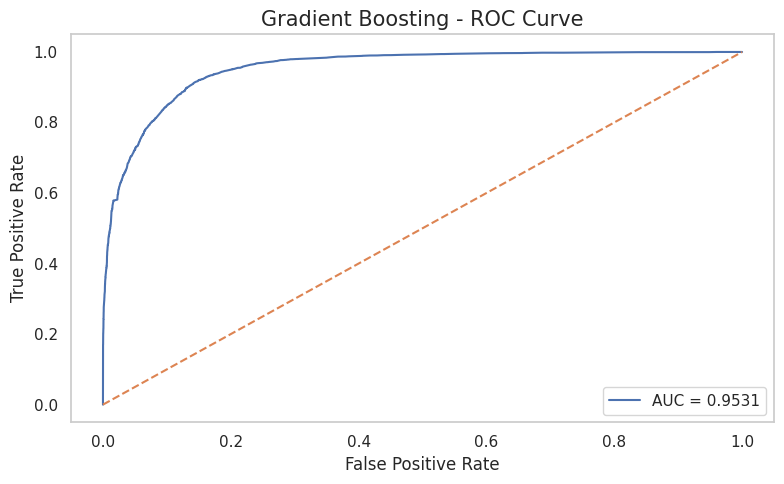

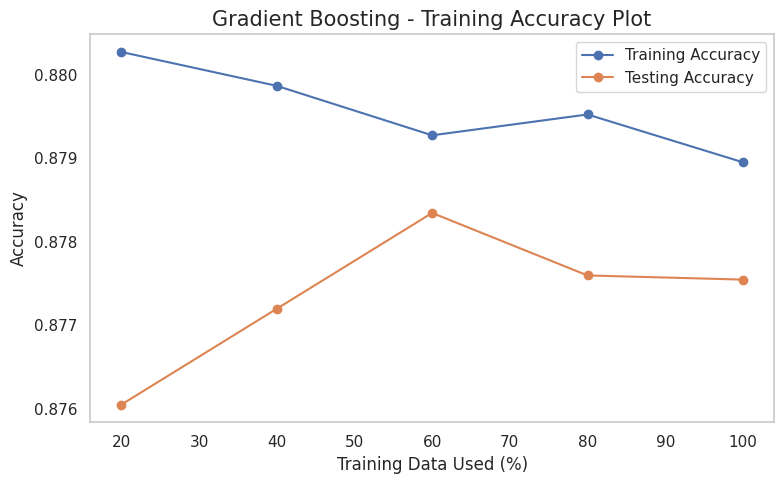


Final Model Comparison


,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.862030,0.861011,0.827189,0.780558,0.803198,0.932902
1,Random Forest,0.920998,0.886691,0.826144,0.871580,0.848254,0.953749
2,Gradient Boosting,0.878955,0.877548,0.786138,0.910766,0.843875,0.953073


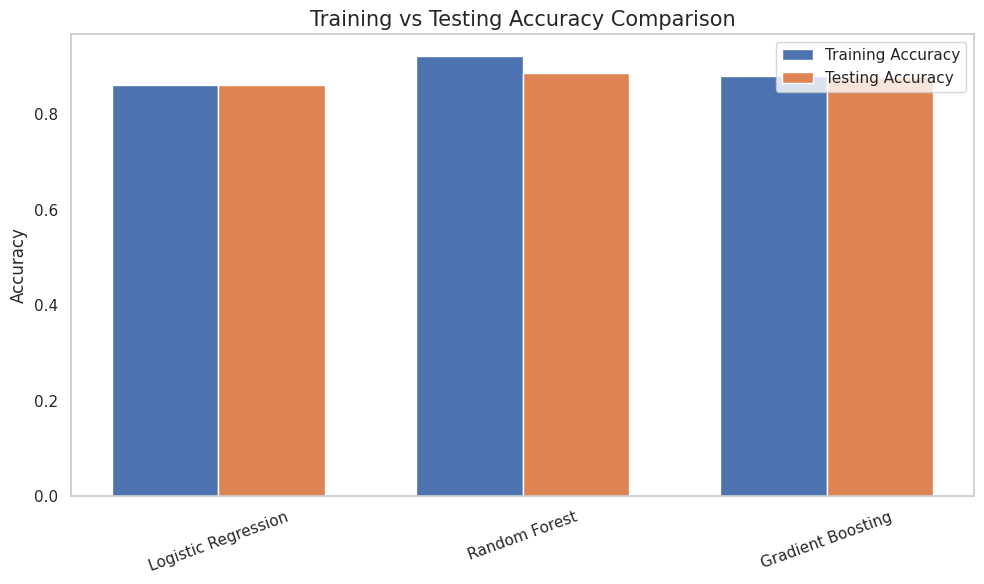

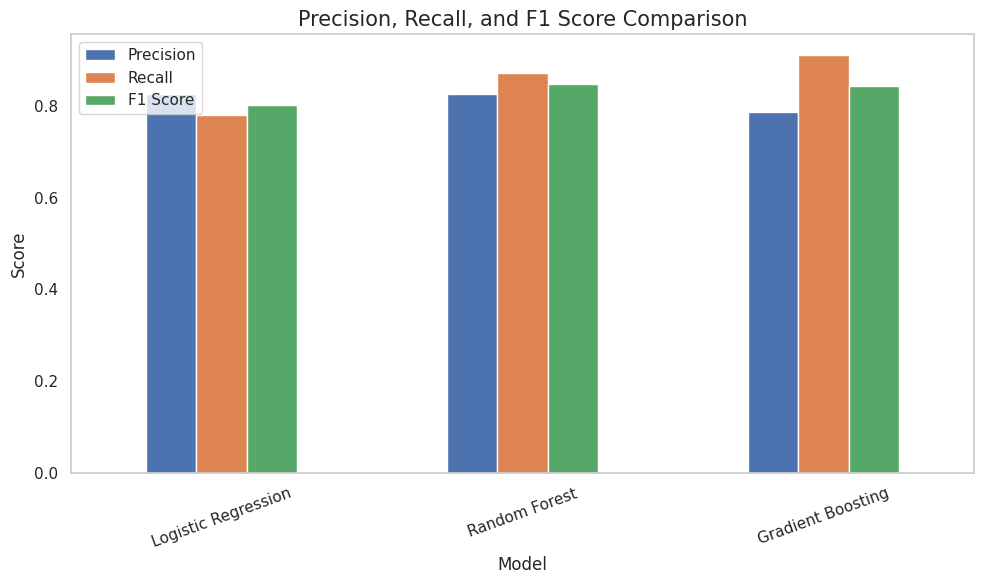

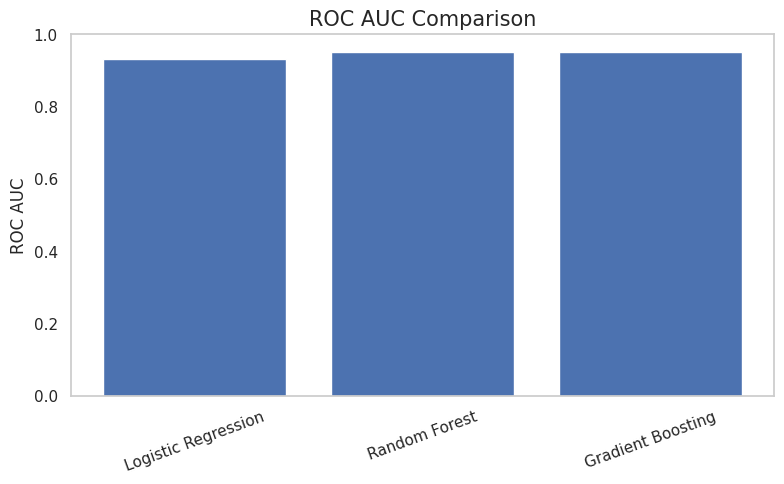

In [ ]:
# =========================
# 3: Gradient Boosting + Final Comparison
# =========================

from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

gb_result = evaluate_model(
    gradient_boosting_model,
    "Gradient Boosting",
    use_sample_weight=True
)

results.append(gb_result)

# -------------------------
# Final comparison table
# -------------------------

results_df = pd.DataFrame(results)

print("\nFinal Model Comparison")
display(results_df)

# -------------------------
# Training vs Testing Accuracy Plot
# -------------------------

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, results_df["Training Accuracy"], width, label="Training Accuracy")
plt.bar(x + width/2, results_df["Testing Accuracy"], width, label="Testing Accuracy")

plt.xticks(x, results_df["Model"], rotation=20)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# -------------------------
# Precision, Recall, F1 Plot
# -------------------------

metric_cols = ["Precision", "Recall", "F1 Score"]

results_df.set_index("Model")[metric_cols].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Precision, Recall, and F1 Score Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# -------------------------
# ROC AUC Comparison Plot
# -------------------------

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["ROC AUC"])
plt.title("ROC AUC Comparison")
plt.ylabel("ROC AUC")
plt.xticks(rotation=20)
plt.grid(False)
plt.tight_layout()
plt.show()